In [1]:
import pandas as pd
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

In [5]:
# Define a list of base paths to the EM files
base_paths = [
    #'',
    '../ma5_test_spin0_pseudo_all/Output/SAF/dmp_1_350/atlas_exot_2018_06/Cutflows/'
]

# List of EM file names
em_file_names = [f'EM{i}.saf' for i in range(13)]

# Define the desired cuts
desired_cuts = [
    'MET > 150 GeV', 'Lepton Veto', 'Njets <= 4', 'dphijmet > 0.4(0.6)',
    
    'Leading jet pT > 150 GeV', 'MET > 200 GeV', '200 < MET < 250 GeV', 
    '250 < MET < 300 GeV', '300 < MET < 350 GeV', '350 < MET < 400 GeV', 
    '400 < MET < 500 GeV', '500 < MET < 600 GeV', '600 < MET < 700 GeV', 
    '700 < MET < 800 GeV', '800 < MET < 900 GeV', '900 < MET < 1000 GeV', 
    '1000 < MET < 1100 GeV', '1100 < MET < 1200 GeV', 'MET < 1200 GeV'
]

# Function to extract relevant cuts and their nentries from a SAF file
def extract_all_cuts_nentries(em_file_path):
    with open(em_file_path, 'r') as file:
        lines = file.readlines()
    nentries = {}
    for i, line in enumerate(lines):
        if line.startswith('<Counter>'):
            cut_name = lines[i + 1].strip().split('"')[1]
            if 'nentries' in lines[i + 2]:
                nentries_value = int(lines[i + 2].split()[0])
                nentries[cut_name] = nentries_value
    return nentries

# Iterate over each base path and create a DataFrame for each
for base_path in base_paths:
    # Collecting nentries from all EM files in the current base path
    em_files_paths = []
    for file_name in em_file_names:
        matched_files = glob.glob(os.path.join(base_path, file_name))
        em_files_paths.extend(matched_files)

    # Notify if no files were found for the current base path
    if not em_files_paths:
        print(f"No input files found for base path: {base_path}")
        continue

    nentries_all_final = {em_file: extract_all_cuts_nentries(em_file) for em_file in em_files_paths}

    # Create the nentries array with relevant cuts
    nentries_array_final_complete = [0] * len(desired_cuts)
    for cuts in nentries_all_final.values():
        for i, cut in enumerate(desired_cuts):
            if cut in cuts:
                nentries_array_final_complete[i] = cuts[cut]

    # Official ATLAS values
    atlas_values = [193090, 187090, 176980, 168960, 90366, 
                60133, 25162, 15549, 8648, 4717, 4034, 1303, 444, 156, 67, 28, 12, 7, 6]

    ma5_values = nentries_array_final_complete

    # Total values for ATLAS and MA5
    total_atlas, total_ma5 = atlas_values[0], ma5_values[0] or 1  # Avoid division by zero

    # error for N for atlas and MA5
    err_atlas_values = [ 1/np.s ]

    # Calculate cumulative efficiencies for ATLAS
    eff_atlas_cumulative = [
        (atlas_values[i] / total_atlas) * 100 for i in range(len(atlas_values))
    ]

    # Calculate cumulative efficiencies for MA5
    eff_ma5_cumulative = [
        (ma5_values[i] / total_ma5) * 100 if total_ma5 > 0 else 0 for i in range(len(ma5_values))
    ]

    # Calculate efficiencies per cut for ATLAS
    eff_atlas = [
        (atlas_values[i] / atlas_values[i - 1]) * 100
        for i in range(1, len(atlas_values))
    ]
    eff_atlas.insert(0, 100)  # Insert 100% for the first cut (initial state)

    # Calculate efficiencies per cut for MA5
    eff_ma5_per_cut = [
        (ma5_values[i] / ma5_values[i - 1]) * 100
        if i > 0 and ma5_values[i] > 0 and ma5_values[i - 1] > 0 else 0
        for i in range(1, len(ma5_values))
    ]
    eff_ma5_per_cut.insert(0, 100)  # Insert 100% for the first cut (initial state)

    # Calculate statistical errors (delta) for MA5 efficiencies per cut
    eff_ma5_delta_per_cut = [
        (eff_ma5_per_cut[i] * np.sqrt(1 / ma5_values[i] + 1 / ma5_values[i - 1]))
        if i > 0 and ma5_values[i] > 0 and ma5_values[i - 1] > 0 else 0
        for i in range(len(ma5_values))
    ]

    # Calculate statistical errors for ATLAS
    eff_atlas_errors = [
        (eff_atlas[i] * np.sqrt(1 / atlas_values[i] + 1 / atlas_values[i - 1]))
        if i > 0 and atlas_values[i] > 0 and atlas_values[i - 1] > 0 else 0
        for i in range(len(atlas_values))
    ]

    # Calculate sigma based on the difference of efficiencies per cut
    sigma_values = [
        abs(eff_atlas[i] - eff_ma5_per_cut[i]) / np.sqrt(eff_atlas_errors[i]**2 + eff_ma5_delta_per_cut[i]**2)
        if eff_atlas_errors[i]**2 + eff_ma5_delta_per_cut[i]**2 > 0 else 0
        for i in range(len(eff_atlas))
    ]

    # Calculate cumulative statistical errors for ATLAS and MA5
    eff_atlas_cumulative_errors = [
        (eff_atlas_cumulative[i] * np.sqrt(1 / atlas_values[i] + 1 / total_atlas))
        if i > 0 and atlas_values[i] > 0 else 0
        for i in range(len(atlas_values))
    ]
    eff_ma5_cumulative_errors = [
        (eff_ma5_cumulative[i] * np.sqrt(1 / ma5_values[i] + 1 / total_ma5))
        if i > 0 and ma5_values[i] > 0 else 0
        for i in range(len(ma5_values))
    ]

    # Calculate sigma based on the cumulative efficiencies
    sigma_cumulative_values = [
        abs(eff_atlas_cumulative[i] - eff_ma5_cumulative[i]) / np.sqrt(eff_atlas_cumulative_errors[i]**2 + eff_ma5_cumulative_errors[i]**2)
        if eff_atlas_cumulative_errors[i]**2 + eff_ma5_cumulative_errors[i]**2 > 0 else 0
        for i in range(len(eff_atlas_cumulative))
    ]

        # Calculate relative differences
    #relative_differences = [
    #    abs(1 - (eff_ma5[i] / eff_atlas[i]))*100 if eff_atlas[i] > 0 else 0
    #    for i in range(len(eff_atlas))
    #]

        # Calculate relative differences
    relative_differences = [
        abs(1 - (eff_ma5_cumulative[i] / eff_atlas_cumulative[i]))*100 if eff_atlas_cumulative[i] > 0 else 0
        for i in range(len(eff_atlas_cumulative))
    ]

# List of EM file names

    # Calculate efficiencies per cut for ATLAS
    #eff_atlas = [
    #    (atlas_values[i] / atlas_values[i - 1]) * 100 if i > 0 and atlas_values[i - 1] > 0 else 100
    #    for i in range(len(atlas_values))
    #]

    # Calculate efficiencies per cut for MA5
   # eff_ma5_per_cut = [
   #    (ma5_values[i] / ma5_values[i - 1]) * 100 if i > 0 and ma5_values[i - 1] > 0 else 100
   #    for i in range(len(ma5_values))
   # ]
   

    # Create DataFrame with the efficiencies, sigma, and relative differences
    DF = {
        "Cuts": [
            r"Total events ($p_{T}^{miss}>150$ GeV)", "Lepton veto", r"$N(j) <= 4$",
            r"min $\Delta \Phi(jets, p_{T}^{miss})$ cut", r"Lead.Jet $p_{T}>150$ GeV $|\eta|<2.4$",
            r"$p_{T}^{miss}>200$ GeV", "EM0", "EM1", "EM2", "EM3", "EM4", "EM5", "EM6",
            "EM7", "EM8", "EM9", "EM10", "EM11", "EM12"
        ],
        "ATLAS Events": atlas_values,
        "MA5 Events": ma5_values,
        #"ATLAS Efficiencies per Cut [%]": eff_atlas,
        "ATLAS Cumulative Efficiencies [%]": eff_atlas_cumulative,
        #"ATLAS Efficiency Errors [%]": eff_atlas_errors,
        #"MA5 Efficiencies per Cut [%]": eff_ma5_per_cut,
        "MA5 Cumulative Efficiencies [%]": eff_ma5_cumulative,
        #"MA5 Delta per Cut [%]": eff_ma5_delta_per_cut,
        #"Sigma (Difference of Efficiencies)": sigma_values,
        "ATLAS Cumulative Errors [%]": eff_atlas_cumulative_errors,
        "MA5 Cumulative Errors [%]": eff_ma5_cumulative_errors,
        "Cumulative Sigma": sigma_cumulative_values,
        "Relative Differences": relative_differences
    }

    df = pd.DataFrame(DF).round(3)

    # Display the DataFrame
    print(f"DataFrame for base path: {base_path}")
    display(df)



DataFrame for base path: ../ma5_test_spin0_pseudo_all/Output/SAF/dmp_1_350/atlas_exot_2018_06/Cutflows/


,Cuts,ATLAS Events,MA5 Events,ATLAS Cumulative Efficiencies [%],MA5 Cumulative Efficiencies [%],ATLAS Cumulative Errors [%],MA5 Cumulative Errors [%],Cumulative Sigma,Relative Differences
0,Total events ($p_{T}^{miss}>150$ GeV),193090,32030,100.000,100.000,0.000,0.000,0.000,0.000
1,Lepton veto,187090,30621,96.893,95.601,0.314,0.764,1.563,1.333
2,$N(j) <= 4$,176980,29840,91.657,93.163,0.302,0.750,1.864,1.643
3,"min $\Delta \Phi(jets, p_{T}^{miss})$ cut",168960,28185,87.503,87.996,0.291,0.719,0.635,0.563
4,Lead.Jet $p_{T}>150$ GeV $|\eta|<2.4$,90366,14040,46.800,43.834,0.189,0.444,6.152,6.338
5,$p_{T}^{miss}>200$ GeV,60133,9204,31.142,28.736,0.145,0.340,6.511,7.729
6,EM0,25162,4357,13.031,13.603,0.087,0.220,2.418,4.387
7,EM1,15549,2292,8.053,7.156,0.067,0.155,5.318,11.138
8,EM2,8648,1165,4.479,3.637,0.049,0.108,7.064,18.789
9,EM3,4717,634,2.443,1.979,0.036,0.079,5.317,18.974


In [35]:
# Define a list of base paths to the EM files
base_paths = [
    #'',
    '../ma5_test_spin0_pseudo_all/Output/SAF/dmp_1_350/atlas_exot_2018_06/Cutflows/'
]

# List of EM file names
em_file_names = [f'EM{i}.saf' for i in range(13)]

# Define the desired cuts
desired_cuts = [
    'MET > 150 GeV', 'Lepton Veto', 'Njets <= 4', 'dphijmet > 0.4(0.6)',
    
    'Leading jet pT > 150 GeV', 'MET > 200 GeV', '200 < MET < 250 GeV', 
    '250 < MET < 300 GeV', '300 < MET < 350 GeV', '350 < MET < 400 GeV', 
    '400 < MET < 500 GeV', '500 < MET < 600 GeV', '600 < MET < 700 GeV', 
    '700 < MET < 800 GeV', '800 < MET < 900 GeV', '900 < MET < 1000 GeV', 
    '1000 < MET < 1100 GeV', '1100 < MET < 1200 GeV', 'MET < 1200 GeV'
]

# Function to extract relevant cuts and their nentries from a SAF file
def extract_all_cuts_nentries(em_file_path):
    with open(em_file_path, 'r') as file:
        lines = file.readlines()
    nentries = {}
    for i, line in enumerate(lines):
        if line.startswith('<Counter>'):
            cut_name = lines[i + 1].strip().split('"')[1]
            if 'nentries' in lines[i + 2]:
                nentries_value = int(lines[i + 2].split()[0])
                nentries[cut_name] = nentries_value
    return nentries

# Iterate over each base path and create a DataFrame for each
for base_path in base_paths:
    # Collecting nentries from all EM files in the current base path
    em_files_paths = []
    for file_name in em_file_names:
        matched_files = glob.glob(os.path.join(base_path, file_name))
        em_files_paths.extend(matched_files)

    # Notify if no files were found for the current base path
    if not em_files_paths:
        print(f"No input files found for base path: {base_path}")
        continue

    nentries_all_final = {em_file: extract_all_cuts_nentries(em_file) for em_file in em_files_paths}

    # Create the nentries array with relevant cuts
    nentries_array_final_complete = [0] * len(desired_cuts)
    for cuts in nentries_all_final.values():
        for i, cut in enumerate(desired_cuts):
            if cut in cuts:
                nentries_array_final_complete[i] = cuts[cut]

    # Official ATLAS values
    atlas_values = [193090, 187090, 176980, 168960, 90366, 
                60133, 25162, 15549, 8648, 4717, 4034, 1303, 444, 156, 67, 28, 12, 7, 6]

    ma5_values = nentries_array_final_complete

    # Total values for ATLAS and MA5
    total_atlas, total_ma5 = atlas_values[0], ma5_values[0] or 1  # Avoid division by zero

    # error for N for atlas and MA5
    err_atlas_values = [ 1 / np.sqrt(atlas_values[i]) for i in range(len(atlas_values)) ]
    err_ma5_values = [ 1 / np.sqrt(ma5_values[i]) if ma5_values[i] > 0 else 0 
                       for i in range(len(atlas_values)) ]

    # Calculate cumulative efficiencies for ATLAS
    eff_atlas_cumulative = [
        (atlas_values[i] / total_atlas) * 100 for i in range(len(atlas_values))
    ]

    # Calculate cumulative efficiencies for MA5
    eff_ma5_cumulative = [
        (ma5_values[i] / total_ma5) * 100 if total_ma5 > 0 else 0 for i in range(len(ma5_values))
    ]

    # Calculate efficiencies per cut for ATLAS
    eff_atlas = [
        (atlas_values[i] / atlas_values[i - 1]) * 100
        for i in range(1, len(atlas_values))
    ]
    eff_atlas.insert(0, 100)  # Insert 100% for the first cut (initial state)

    # Calculate efficiencies per cut for MA5
    eff_ma5_per_cut = [
        (ma5_values[i] / ma5_values[i - 1]) * 100
        if i > 0 and ma5_values[i] > 0 and ma5_values[i - 1] > 0 else 0
        for i in range(1, len(ma5_values))
    ]
    eff_ma5_per_cut.insert(0, 100)  # Insert 100% for the first cut (initial state)

    # Calculate statistical errors (delta) for MA5 efficiencies per cut
    eff_ma5_delta_per_cut = [
        (eff_ma5_per_cut[i] * np.sqrt(1 / ma5_values[i] + 1 / ma5_values[i - 1]))
        if i > 0 and ma5_values[i] > 0 and ma5_values[i - 1] > 0 else 0
        for i in range(len(ma5_values))
    ]

    # Calculate statistical errors for ATLAS
    eff_atlas_errors = [
        (eff_atlas[i] * err_atlas_values[i] / atlas_values[i])
        if i > 0 and atlas_values[i] > 0 and atlas_values[i - 1] > 0 else 0
        for i in range(len(atlas_values))
    ]

    # Calculate sigma based on the difference of efficiencies per cut
    sigma_values = [
        abs(eff_atlas[i] - eff_ma5_per_cut[i]) / np.sqrt(eff_atlas_errors[i]**2 + eff_ma5_delta_per_cut[i]**2)
        if eff_atlas_errors[i]**2 + eff_ma5_delta_per_cut[i]**2 > 0 else 0
        for i in range(len(eff_atlas))
    ]

    # Calculate cumulative statistical errors for ATLAS and MA5
    eff_atlas_cumulative_errors = [
        (eff_atlas_cumulative[i] * err_atlas_values[i] / atlas_values[i])
        if atlas_values[i] > 0 else 0
        for i in range(len(atlas_values))
    ]
    eff_ma5_cumulative_errors = [
        (eff_ma5_cumulative[i] * err_ma5_values[i] / ma5_values[i])
        if ma5_values[i] > 0 else 0
        for i in range(len(ma5_values))
    ]

    # Calculate sigma based on the cumulative efficiencies
    sigma_cumulative_values = [
        abs(eff_atlas_cumulative[i] - eff_ma5_cumulative[i]) / np.sqrt(eff_atlas_cumulative_errors[i]**2 + eff_ma5_cumulative_errors[i]**2)
        if eff_atlas_cumulative_errors[i]**2 + eff_ma5_cumulative_errors[i]**2 > 0 else 0
        for i in range(len(eff_atlas_cumulative))
    ]

        # Calculate relative differences
    #relative_differences = [
    #    abs(1 - (eff_ma5[i] / eff_atlas[i]))*100 if eff_atlas[i] > 0 else 0
    #    for i in range(len(eff_atlas))
    #]

        # Calculate relative differences
    relative_differences = [
        abs(1 - (eff_ma5_cumulative[i] / eff_atlas_cumulative[i]))*100 if eff_atlas_cumulative[i] > 0 else 0
        for i in range(len(eff_atlas_cumulative))
    ]

# List of EM file names

    # Calculate efficiencies per cut for ATLAS
    #eff_atlas = [
    #    (atlas_values[i] / atlas_values[i - 1]) * 100 if i > 0 and atlas_values[i - 1] > 0 else 100
    #    for i in range(len(atlas_values))
    #]

    # Calculate efficiencies per cut for MA5
   # eff_ma5_per_cut = [
   #    (ma5_values[i] / ma5_values[i - 1]) * 100 if i > 0 and ma5_values[i - 1] > 0 else 100
   #    for i in range(len(ma5_values))
   # ]
   

    # Create DataFrame with the efficiencies, sigma, and relative differences
    DF = {
        "Cuts": [
            r"Total events ($p_{T}^{miss}>150$ GeV)", "Lepton veto", r"$N(j) <= 4$",
            r"min $\Delta \Phi(jets, p_{T}^{miss})$ cut", r"Lead.Jet $p_{T}>150$ GeV $|\eta|<2.4$",
            r"$p_{T}^{miss}>200$ GeV", "EM0", "EM1", "EM2", "EM3", "EM4", "EM5", "EM6",
            "EM7", "EM8", "EM9", "EM10", "EM11", "EM12"
        ],
        "ATLAS Events": atlas_values,
        "MA5 Events": ma5_values,
        #"ATLAS Efficiencies per Cut [%]": eff_atlas,
        "ATLAS Cumulative Efficiencies [%]": eff_atlas_cumulative,
        #"ATLAS Efficiency Errors [%]": eff_atlas_errors,
        #"MA5 Efficiencies per Cut [%]": eff_ma5_per_cut,
        "MA5 Cumulative Efficiencies [%]": eff_ma5_cumulative,
        #"MA5 Delta per Cut [%]": eff_ma5_delta_per_cut,
        #"Sigma (Difference of Efficiencies)": sigma_values,
        "ATLAS Cumulative Errors [%]": eff_atlas_cumulative_errors,
        "MA5 Cumulative Errors [%]": eff_ma5_cumulative_errors,
        "Cumulative Sigma": sigma_cumulative_values,
        "Relative Differences": relative_differences
    }

    df = pd.DataFrame(DF).round(3)

    # Display the DataFrame
    print(f"DataFrame for base path: {base_path}")
    display(df)



DataFrame for base path: ../ma5_test_spin0_pseudo_all/Output/SAF/dmp_1_350/atlas_exot_2018_06/Cutflows/


,Cuts,ATLAS Events,MA5 Events,ATLAS Cumulative Efficiencies [%],MA5 Cumulative Efficiencies [%],ATLAS Cumulative Errors [%],MA5 Cumulative Errors [%],Cumulative Sigma,Relative Differences
0,Total events ($p_{T}^{miss}>150$ GeV),193090,32030,100.000,100.000,0.0,0.000,0.000,0.000
1,Lepton veto,187090,30621,96.893,95.601,0.0,0.000,72232.545,1.333
2,$N(j) <= 4$,176980,29840,91.657,93.163,0.0,0.000,83129.089,1.643
3,"min $\Delta \Phi(jets, p_{T}^{miss})$ cut",168960,28185,87.503,87.996,0.0,0.000,26416.953,0.563
4,Lead.Jet $p_{T}>150$ GeV $|\eta|<2.4$,90366,14040,46.800,43.834,0.0,0.000,112328.504,6.338
5,$p_{T}^{miss}>200$ GeV,60133,9204,31.142,28.736,0.0,0.000,73806.195,7.729
6,EM0,25162,4357,13.031,13.603,0.0,0.000,12057.123,4.387
7,EM1,15549,2292,8.053,7.156,0.0,0.000,13725.995,11.138
8,EM2,8648,1165,4.479,3.637,0.0,0.000,9182.981,18.789
9,EM3,4717,634,2.443,1.979,0.0,0.000,3731.274,18.974


In [42]:
n_a = 187090
N_a = 193090
dn_a = 1 / np.sqrt(n_a)
e_a = n_a / N_a
de_a = dn_a * e_a / N_a
print(n_a, N_a, dn_a, e_a, de_a)

187090 193090 0.0023119301704059743 0.9689264073747993 1.1601275022594998e-08


In [43]:
df['MA5 Cumulative Errors [%]']/df['MA5 Cumulative Efficiencies [%]']

0     0.000000
1     0.000000
2     0.000000
3     0.000000
4     0.000000
5     0.000000
6     0.000000
7     0.000000
8     0.000000
9     0.000000
10    0.000000
11    0.000000
12    0.000000
13    0.013889
14    0.045455
15    0.166667
16         NaN
17    1.000000
18         NaN
dtype: float64

In [44]:
df.columns

Index(['Cuts', 'ATLAS Events', 'MA5 Events',
       'ATLAS Cumulative Efficiencies [%]', 'MA5 Cumulative Efficiencies [%]',
       'ATLAS Cumulative Errors [%]', 'MA5 Cumulative Errors [%]',
       'Cumulative Sigma', 'Relative Differences'],
      dtype='object')

In [45]:
atlas_df = df[['Cuts', 'ATLAS Cumulative Efficiencies [%]', 'ATLAS Cumulative Errors [%]']]

In [46]:
atlas_df.to_csv('df_ATLAS.csv')

In [47]:
ma5_match_df = df[['Cuts', 'MA5 Cumulative Efficiencies [%]', 'MA5 Cumulative Errors [%]', 'Relative Differences']]

In [48]:
ma5_match_df.to_csv('df_ma5_match_pseudo.csv')

In [49]:
import csv

In [50]:
x_atlas = []
y = []
y_err = []
with open('df_ATLAS.csv') as atlas_csv:
    atlas_pts = csv.reader(atlas_csv, delimiter = ',')
    for row in atlas_pts:
        x_atlas.append(row[1])
        y.append(row[2])
        y_err.append(row[3])

y_atlas = list(map(float, y[1:]))
y_err_atlas = list(map(float, y_err[1:]))

In [51]:
x_ma5 = []
y = []
y_err = []
rel_diff = []
with open('df_ma5_match_pseudo.csv') as atlas_csv:
    atlas_pts = csv.reader(atlas_csv, delimiter = ',')
    for row in atlas_pts:
        x_ma5.append(row[1])
        y.append(row[2])
        y_err.append(row[3])
        rel_diff.append(row[4])

y_ma5 = list(map(float, y[1:]))
y_err_ma5 = list(map(float, y_err[1:]))
rel_diff_ma5 = list(map(float, rel_diff[1:]))

In [52]:
x_ma5_match = []
y = []
y_err = []
rel_diff = []
with open('df_ma5_match.csv') as atlas_csv:
    atlas_pts = csv.reader(atlas_csv, delimiter = ',')
    for row in atlas_pts:
        x_ma5_match.append(row[1])
        y.append(row[2])
        y_err.append(row[3])
        rel_diff.append(row[4])

y_ma5_match = list(map(float, y[1:]))
y_err_ma5_match = list(map(float, y_err[1:]))
rel_diff_ma5_match = list(map(float, rel_diff[1:]))

In [53]:
len(list(range(0, 36, 2)))

18

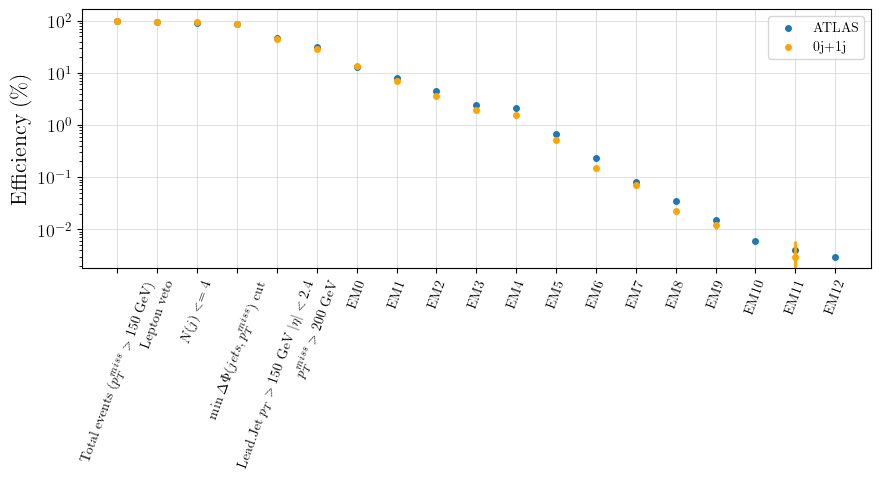

In [59]:
plt.scatter(range(len(x_atlas[1:])), np.array(y_atlas), label='ATLAS')
plt.scatter(range(len(x_atlas[1:])), np.array(y_ma5), label='0j+1j', color='orange')
# plt.scatter(range(len(x_atlas[1:])), y_ma5_match, label=r'0j+1j', color='green')

plt.errorbar(range(len(x_atlas[1:])), np.array(y_atlas), yerr=np.array(y_err_atlas), ls='')
plt.errorbar(range(len(x_atlas[1:])), np.array(y_ma5), yerr=np.array(y_err_ma5), color='orange', ls='')
# plt.errorbar(range(len(x_atlas[1:])), y_ma5_match, yerr=y_err_ma5_match, color='green', ls='')

# plt.scatter(x_atlas[1:], y_atlas)

plt.yscale('log')

plt.xticks(range(len(x_atlas[1:])), x_atlas[1:])
plt.xticks(rotation=70, fontsize = 10)
plt.rcParams["figure.figsize"] = (9,6)
plt.ylabel(r'Efficiency (\%)')
plt.legend()
plt.tight_layout()

plt.savefig('./cutflow_pseudoscalar_comp.png')

plt.show()

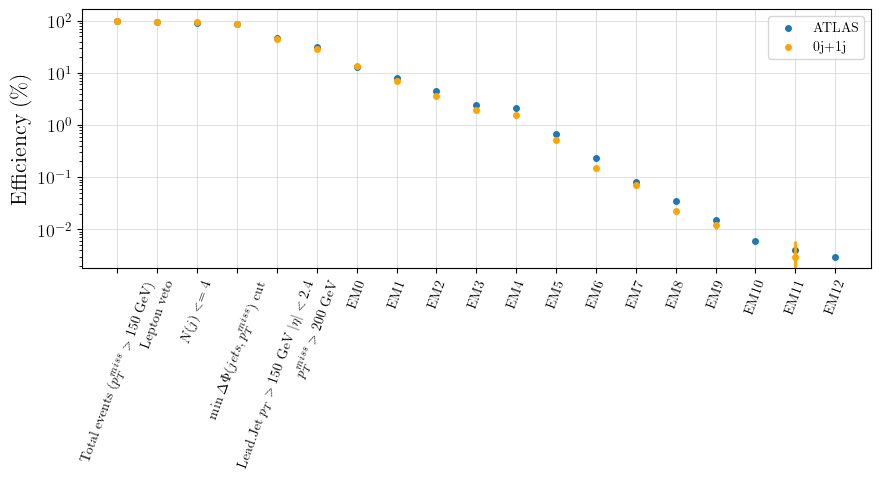

In [59]:
plt.scatter(range(len(x_atlas[1:])), np.array(y_atlas), label='ATLAS')
plt.scatter(range(len(x_atlas[1:])), np.array(y_ma5), label='0j+1j', color='orange')
# plt.scatter(range(len(x_atlas[1:])), y_ma5_match, label=r'0j+1j', color='green')

plt.errorbar(range(len(x_atlas[1:])), np.array(y_atlas), yerr=np.array(y_err_atlas), ls='')
plt.errorbar(range(len(x_atlas[1:])), np.array(y_ma5), yerr=np.array(y_err_ma5), color='orange', ls='')
# plt.errorbar(range(len(x_atlas[1:])), y_ma5_match, yerr=y_err_ma5_match, color='green', ls='')

# plt.scatter(x_atlas[1:], y_atlas)

plt.yscale('log')

plt.xticks(range(len(x_atlas[1:])), x_atlas[1:])
plt.xticks(rotation=70, fontsize = 10)
plt.rcParams["figure.figsize"] = (9,6)
plt.ylabel(r'Efficiency (\%)')
plt.legend()
plt.tight_layout()

# plt.savefig('./cutflow_pseudoscalar_comp.png')

plt.show()

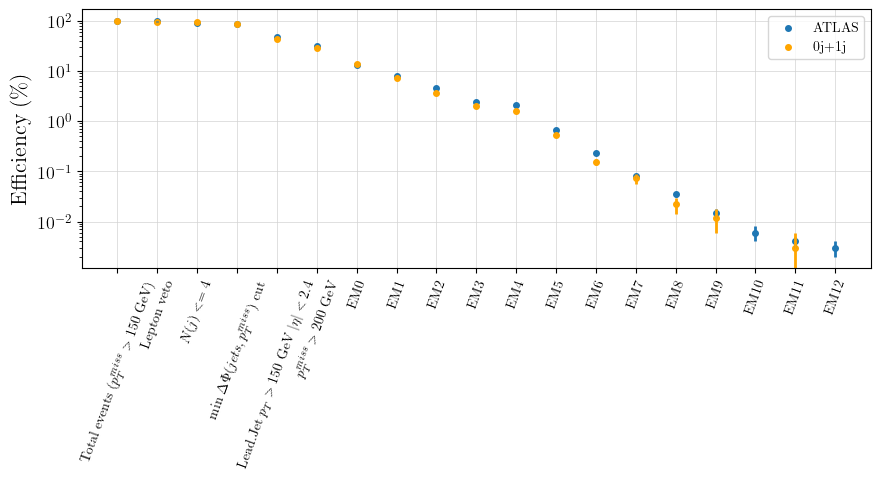

In [33]:
plt.scatter(range(len(x_atlas[1:])), np.array(y_atlas), label='ATLAS')
plt.scatter(range(len(x_atlas[1:])), np.array(y_ma5), label='0j+1j', color='orange')
# plt.scatter(range(len(x_atlas[1:])), y_ma5_match, label=r'0j+1j', color='green')

plt.errorbar(range(len(x_atlas[1:])), np.array(y_atlas), yerr=np.array(y_err_atlas), ls='')
plt.errorbar(range(len(x_atlas[1:])), np.array(y_ma5), yerr=np.array(y_err_ma5), color='orange', ls='')
# plt.errorbar(range(len(x_atlas[1:])), y_ma5_match, yerr=y_err_ma5_match, color='green', ls='')

# plt.scatter(x_atlas[1:], y_atlas)

plt.yscale('log')

plt.xticks(range(len(x_atlas[1:])), x_atlas[1:])
plt.xticks(rotation=70, fontsize = 10)
plt.rcParams["figure.figsize"] = (9,5)
plt.ylabel(r'Efficiency (\%)')
plt.legend()
plt.tight_layout()

plt.show()

/tmp/ipykernel_54749/105777971.py:4: RuntimeWarning: divide by zero encountered in divide
  diffErr = (np.array(y_ma5) - np.array(y_atlas))/np.sqrt(np.array(y_err_atlas)**2 + np.array(y_err_ma5)**2)
/tmp/ipykernel_54749/105777971.py:4: RuntimeWarning: invalid value encountered in divide
  diffErr = (np.array(y_ma5) - np.array(y_atlas))/np.sqrt(np.array(y_err_atlas)**2 + np.array(y_err_ma5)**2)


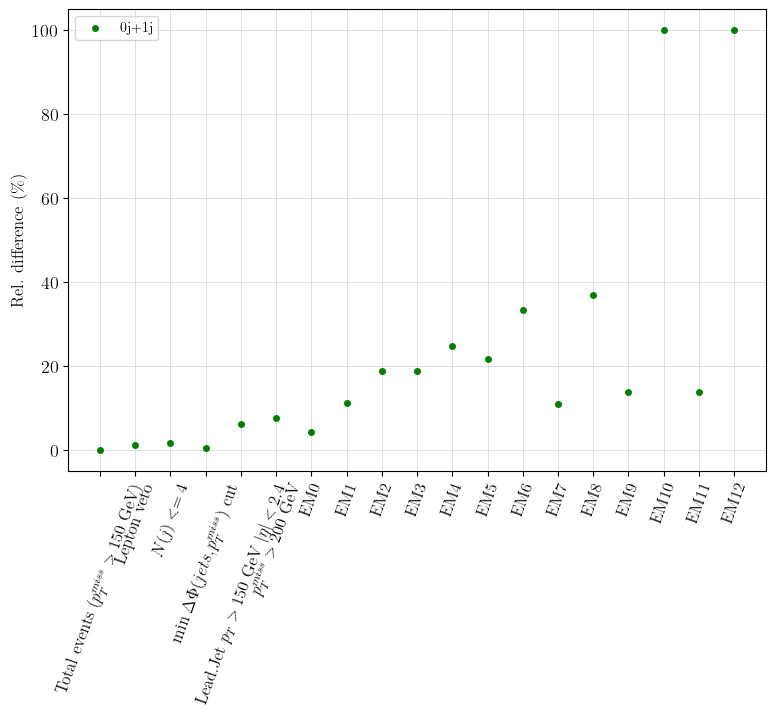

In [60]:
# plt.scatter(range(len(x_ma5[1:])), rel_diff_ma5, label='1j', color='orange')
plt.scatter(range(len(x_ma5[1:])), rel_diff_ma5, label=r'0j+1j', color='green')

diffErr = (np.array(y_ma5) - np.array(y_atlas))/np.sqrt(np.array(y_err_atlas)**2 + np.array(y_err_ma5)**2)
# plt.scatter(x_atlas[1:], y_atlas)

# plt.yscale('log')
# plt.hlines(25, 0, 18, ls='--', color='gray')

plt.xticks(range(len(x_ma5[1:])), x_ma5[1:])
plt.xticks(rotation=70, fontsize = 12)
plt.rcParams["figure.figsize"] = (10,4)
plt.ylabel(r'Rel. difference (\%)', fontsize=12)
plt.legend()

# plt.tight_layout()

# plt.savefig('rel_diff_eff.png')
plt.show()

In [61]:
diffErr

array([         nan,         -inf,          inf,          inf,
               -inf,         -inf,          inf,         -inf,
               -inf,         -inf,         -inf,         -inf,
               -inf,  -9.        , -13.        ,  -1.5       ,
               -inf,  -0.33333333,         -inf])

In [10]:
y_atlas[1:]

['100.0',
 '95.195',
 '91.957',
 '88.543',
 '64.598',
 '51.712',
 '13.091',
 '10.163',
 '7.499',
 '5.369',
 '6.652',
 '3.608',
 '2.062',
 '1.225',
 '0.768',
 '0.467',
 '0.282',
 '0.185',
 '0.34']

In [11]:
for row in plots:
    print(row)

ValueError: I/O operation on closed file.